<a href="https://www.kaggle.com/code/anaitlo/smartmobilityforasustainableworld?scriptVersionId=282970356" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Problem Statement

Traditional autonomous vehicle (AV) systems exhibit several critical limitations. They rely on rigid, rule-based controllers, cannot merge heterogeneous streams of information, and fail to communicate intention or reason explicitly about trade-offs. Moreover, current approaches do not incorporate sustainability metrics into action-level decisions and cannot resolve conflicting signals arising from multiple policies (e.g., safety vs. eco vs. comfort). As a result, existing algorithms often produce reasonable local decisions but poor global or sustainability-aware decisions.

## Core Problem

The central challenge addressed in this work is:

   
*How do we design a smart autonomous vehicle that can make sustainable, safe, and efficient decisions in real-time traffic balancing safety, comfort, eco-driving, and cooperation using a decision brain powered by LLMs and AI agents?*


## Proposed Solution

To overcome these limitations, we introduce a hybrid agentic decision framework supervised by Large Language Models (LLMs). This framework integrates perception, multi-policy evaluation, sustainability-aware reward structures, and LLM-based global action arbitration. The architecture consists of the following components as you see in the imag below:

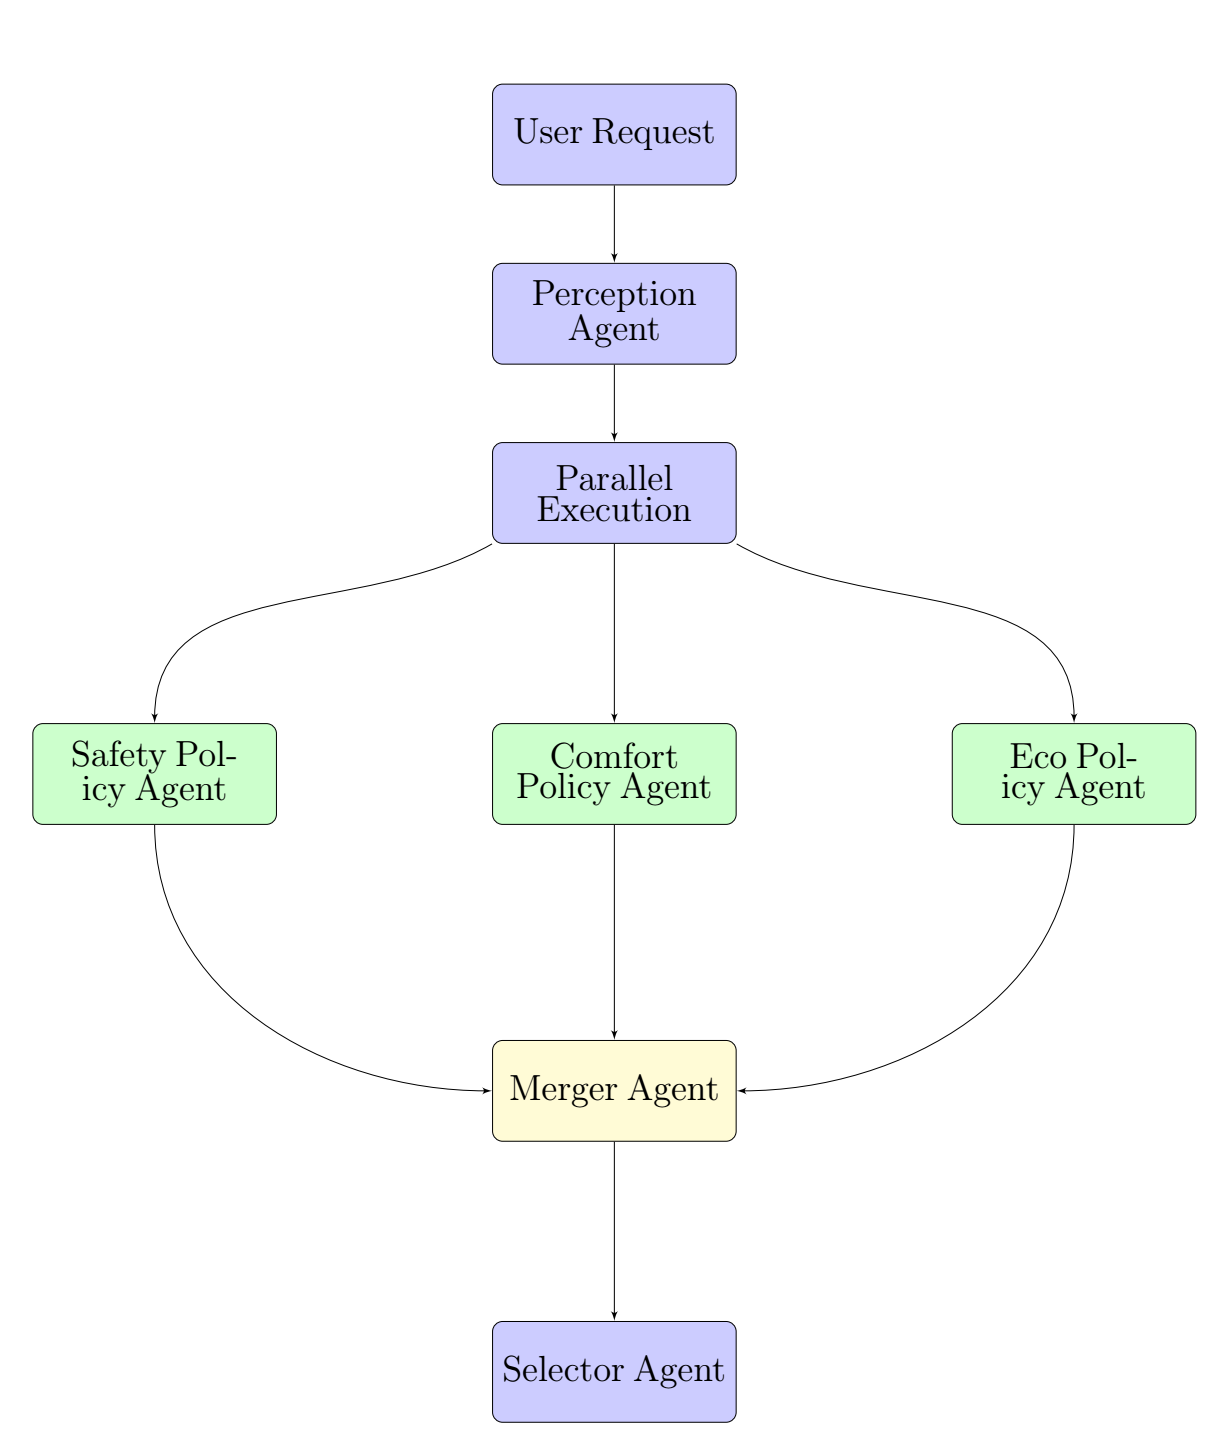

### User Request
The pipeline begins with a user-defined scenario containing the **vehicle_id**, the full **world_state**, and contextual information such as weather, traffic density, and energy status. This input initializes the decision-making chain.

### Perception Agent
The Perception Agent processes the raw world state and constructs an enriched representation of the AV. This includes metrics related to safety (e.g., headway, time-to-collision), comfort (e.g., jerk), eco-efficiency (SoC/SoH), and environmental context. The resulting unified state serves as input for all downstream agents.

### Parallel Execution Layer
The enriched perception output is dispatched in parallel to three specialized policy agents Safety, Comfort, and Eco enabling independent multi-objective evaluation.

### Safety Policy Agent
This agent evaluates collision risk, braking safety, legal constraints, and lane-change feasibility. It outputs a safety score, a recommended safe action, and a concise justification.

### Comfort Policy Agent
This agent assesses passenger comfort by analyzing jerk, smoothness, lateral stability, and acceleration limits. It provides a comfort score, an optimal comfort-oriented action, and explanatory reasoning.

### Eco Policy Agent
Focusing on sustainability, this agent optimizes eco-driving behavior by considering eco-deceleration, battery health (SoC/SoH), emissions, and energy efficiency. It outputs an eco-efficiency score, an eco-optimal action, and an environmental justification.

### Merger Agent (LLM Arbiter)
The Merger Agent aggregates all policy outputs and, using LLM-based reasoning, resolves conflicts, weighs trade-offs, and selects the globally optimal action. It produces a transparent, human-readable explanation of the final decision.

### Selector Agent
This component returns the final chosen action, including a structured breakdown of policy scores, the sustainability assessment, and the LLM-generated justification.

## Value Proposition

The proposed architecture delivers a unified and robust decision-making framework by decomposing safety, comfort, and sustainability into specialized agents and reconciling them through LLM-based multi-objective reasoning. By incorporating eco-driving strategies and energy-aware policies, the system aligns with smart-city sustainability goals and reduces environmental impact. From an industrial perspective, the architecture serves as a flexible software-based decision layer supporting personalized driving modes and offering seamless integration with cloud intelligence and cooperative fleet systems. This makes the framework a strategically valuable foundation for next-generation mobility ecosystems.


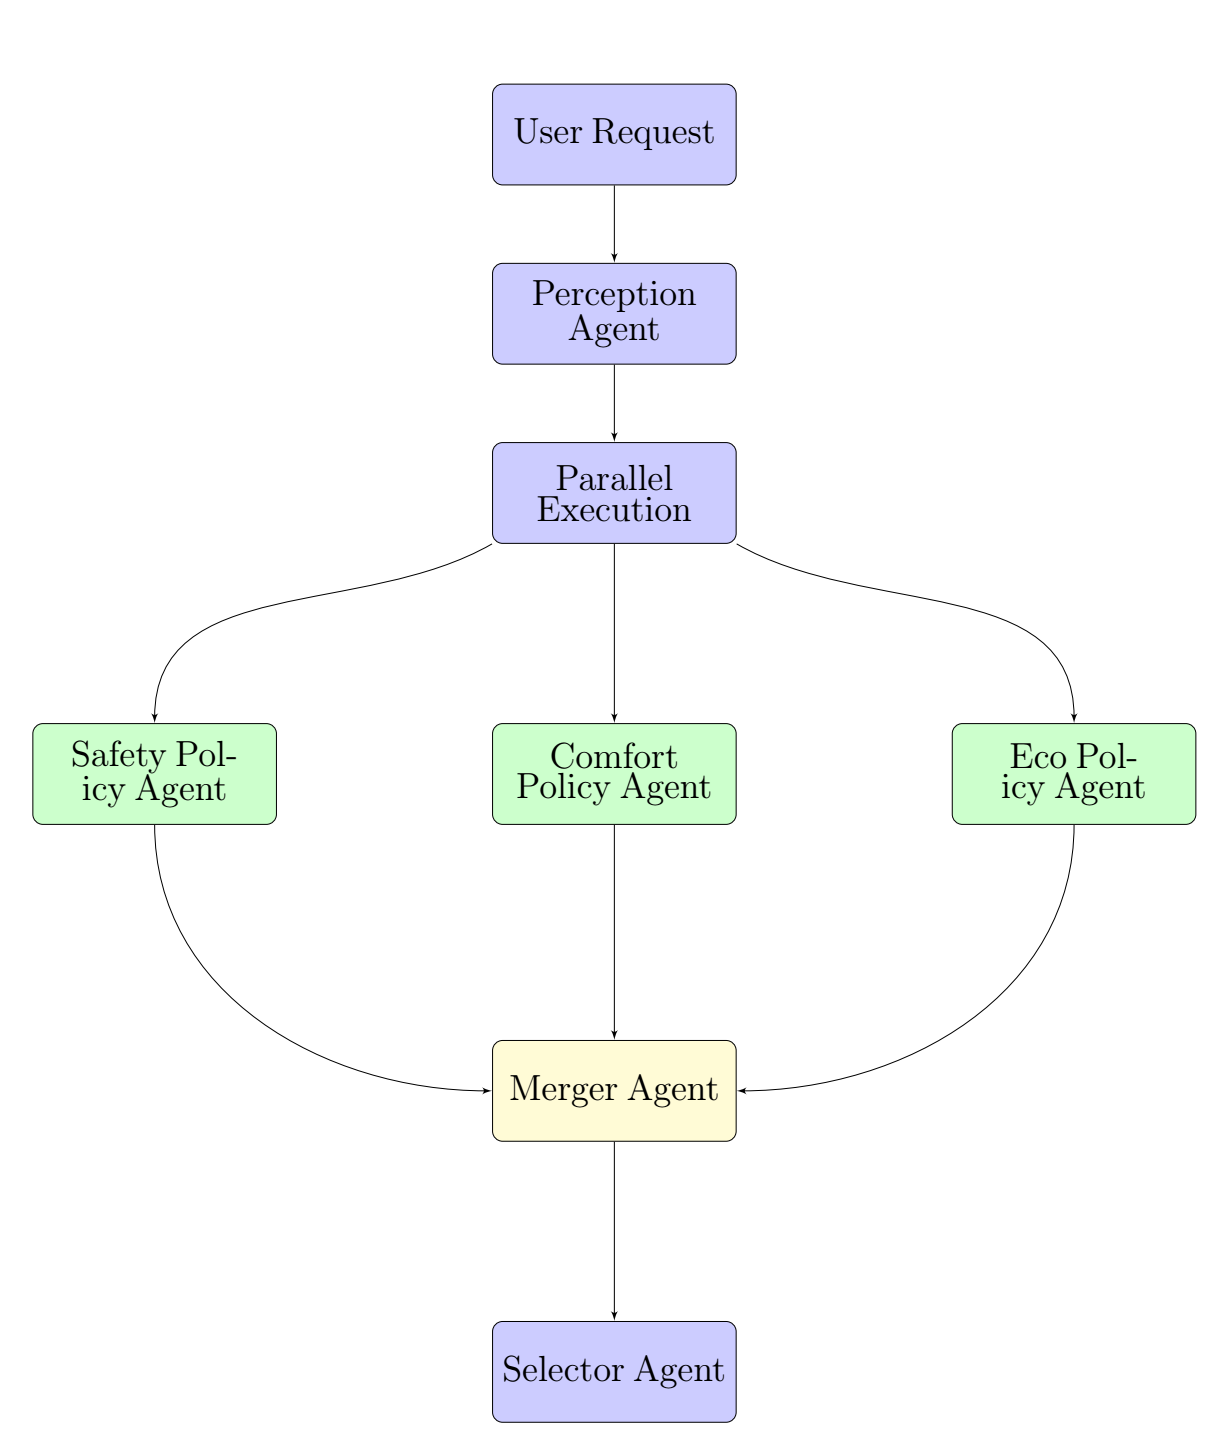

In [1]:
import os
from kaggle_secrets import UserSecretsClient

try:
    GOOGLE_API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")
    os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
    print("✅ Gemini API key setup complete.")
except Exception as e:
    print(
        f"🔑 Authentication Error: Please make sure you have added 'GOOGLE_API_KEY' to your Kaggle secrets. Details: {e}"
    )

✅ Gemini API key setup complete.


In [2]:
import logging
import os

# Clean up any previous logs
for log_file in ["logger.log", "web.log", "tunnel.log"]:
    if os.path.exists(log_file):
        os.remove(log_file)
        print(f"🧹 Cleaned up {log_file}")

# Configure logging with DEBUG log level.
logging.basicConfig(
    filename="logger.log",
    level=logging.DEBUG,
    format="%(filename)s:%(lineno)s %(levelname)s:%(message)s",
)

print("✅ Logging configured")

✅ Logging configured


In [3]:
# Define helper functions that will be reused throughout the notebook

from IPython.core.display import display, HTML
from jupyter_server.serverapp import list_running_servers


# Gets the proxied URL in the Kaggle Notebooks environment
def get_adk_proxy_url():
    PROXY_HOST = "https://kkb-production.jupyter-proxy.kaggle.net"
    ADK_PORT = "8000"

    servers = list(list_running_servers())
    if not servers:
        raise Exception("No running Jupyter servers found.")

    baseURL = servers[0]["base_url"]

    try:
        path_parts = baseURL.split("/")
        kernel = path_parts[2]
        token = path_parts[3]
    except IndexError:
        raise Exception(f"Could not parse kernel/token from base URL: {baseURL}")

    url_prefix = f"/k/{kernel}/{token}/proxy/proxy/{ADK_PORT}"
    url = f"{PROXY_HOST}{url_prefix}"

    styled_html = f"""
    <div style="padding: 15px; border: 2px solid #f0ad4e; border-radius: 8px; background-color: #fef9f0; margin: 20px 0;">
        <div style="font-family: sans-serif; margin-bottom: 12px; color: #333; font-size: 1.1em;">
            <strong>⚠️ IMPORTANT: Action Required</strong>
        </div>
        <div style="font-family: sans-serif; margin-bottom: 15px; color: #333; line-height: 1.5;">
            The ADK web UI is <strong>not running yet</strong>. You must start it in the next cell.
            <ol style="margin-top: 10px; padding-left: 20px;">
                <li style="margin-bottom: 5px;"><strong>Run the next cell</strong> (the one with <code>!adk web ...</code>) to start the ADK web UI.</li>
                <li style="margin-bottom: 5px;">Wait for that cell to show it is "Running" (it will not "complete").</li>
                <li>Once it's running, <strong>return to this button</strong> and click it to open the UI.</li>
            </ol>
            <em style="font-size: 0.9em; color: #555;">(If you click the button before running the next cell, you will get a 500 error.)</em>
        </div>
        <a href='{url}' target='_blank' style="
            display: inline-block; background-color: #1a73e8; color: white; padding: 10px 20px;
            text-decoration: none; border-radius: 25px; font-family: sans-serif; font-weight: 500;
            box-shadow: 0 2px 5px rgba(0,0,0,0.2); transition: all 0.2s ease;">
            Open ADK Web UI (after running cell below) ↗
        </a>
    </div>
    """

    display(HTML(styled_html))

    return url_prefix


print("✅ Helper functions defined.")

✅ Helper functions defined.


In [4]:
#!rm -rf avsustenibility
#!adk create avsustenibility --model gemini-2.5-flash-lite --api_key $GOOGLE_API_KEY

In [5]:
# %%writefile avsustenibility/agent.py



# ---- Standard Library ----
import math
import json
from typing import Dict, Any, List, Optional, Literal

# ---- Pydantic ----
from pydantic import BaseModel, Field

# ---- ADK Agents & Tools ----
from google.adk.agents import LlmAgent, SequentialAgent, ParallelAgent
from google.adk.tools import FunctionTool

# ---- ADK runners (optional for debugging) ----
from google.adk.runners import InMemoryRunner

# ---- Google GenAI ----
from google import genai
from google.genai import types



retry_config=types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1, # Initial delay before first retry (in seconds)
    http_status_codes=[429, 500, 503, 504] # Retry on these HTTP errors
)

VehicleAction = Literal[
    "KEEP_LANE",
    "ACCELERATE",
    "BRAKE",
    "LANE_LEFT",
    "LANE_RIGHT",
]

# ---------------------------
# 1. Perception IO
# ---------------------------
class PerceptionInput(BaseModel):
    vehicle_id: str
    world_state: Dict[str, Any]
    base_policy_name: str
    base_action:str


class PerceptionState(BaseModel):
    lane: int
    position_m: float
    speed_mps: float
    accel_mps2: float
    length_m: float
    is_av: bool

    # Enriched metrics for sustainability / comfort
    headway_m: Optional[float] = Field(
        None, description="Distance to lead vehicle in same lane, meters."
    )
    headway_time_s: Optional[float] = Field(
        None, description="Time-gap to lead vehicle in seconds."
    )
    jerk_est: Optional[float] = Field(
        None, description="Approximate jerk (change in acceleration) in m/s^3."
    )
    soc: Optional[float] = Field(
        None, description="Battery state of charge [%]."
    )
    soh: Optional[float] = Field(
        None, description="Battery state of health [%]."
    )
    battery_temp_C: Optional[float] = Field(
        None, description="Battery temperature in °C."
    )


class PerceptionOutput(BaseModel):
    vehicle_id: str
    state: PerceptionState
    world_state: Dict[str, Any]
    base_policy_name: str = Field(..., description="Base policy name.")
    base_action: VehicleAction = Field(..., description="Base action from sequential policy.")
    error: Optional[str] = None
    note: Optional[str] = None


class SinglePolicyOutput(BaseModel):
    policy_name: str
    score: float
    suggested_action: VehicleAction
    explanation: str
    base_policy_name: str = Field(..., description="Base policy name.")
    base_action: VehicleAction = Field(..., description="Base action from sequential policy.")
    error: Optional[str] = None

class MergerOutput(BaseModel):
    chosen_action: VehicleAction
    chosen_policy: str
    scores: Dict[str, float]
    base_action: VehicleAction
    reasoning: str

def compute_perception(world_state: Dict[str, Any], vehicle_id: str) -> Dict[str, Any]:
    """
    Pure Python numeric perception.
    Returns:
    {
        "state": {...},      # enriched local AV state
        "vehicle_id": str,
        "world_state": {...}
    }
    """

    vehicles = world_state.get("vehicles", [])
    ego: Optional[Dict[str, Any]] = next(
        (v for v in vehicles if v.get("id") == vehicle_id),
        None
    )

    if ego is None:
        raise ValueError(f"Vehicle {vehicle_id} not found in world_state.")

    # --- Extract ego attributes ---
    lane = ego.get("lane", 0)
    position = float(ego.get("position", 0.0))
    speed = float(ego.get("v", 0.0))
    accel = float(ego.get("a", 0.0))
    length = float(ego.get("length", 4.5))

    soc = float(ego.get("soc", 100.0))
    soh = float(ego.get("soh", 100.0))
    temp = float(ego.get("battery_temp_C", 25.0))
    is_av = bool(ego.get("is_av", False))

    # --- Compute HEADWAY to nearest lead vehicle in same lane ---
    lead_vehicle = None
    min_d = math.inf

    for v in vehicles:
        if v.get("lane") == lane and v.get("id") != vehicle_id:
            dv = v.get("position", 0.0) - position
            if dv > 0 and dv < min_d:
                min_d = dv
                lead_vehicle = v

    if lead_vehicle:
        headway_m = float(lead_vehicle.get("position", 0.0)) - position - length
        lead_speed = float(lead_vehicle.get("v", 0.0))
        rel_speed = max(speed - lead_speed, 0.1)
        headway_time_s = headway_m / rel_speed if rel_speed > 0 else 999.0
    else:
        headway_m = 999.0
        headway_time_s = 999.0

    # --- Compute jerk ---
    jerk_est = 0.0  # cannot compute from single frame; OK for 1-step sim

    # --- Build enriched state ---
    perception_state = {
        "lane": lane,
        "position_m": position,
        "speed_mps": speed,
        "accel_mps2": accel,
        "length_m": length,
        "soc": soc,
        "soh": soh,
        "battery_temp_C": temp,
        "is_av": is_av,

        # derived
        "headway_m": headway_m,
        "headway_time_s": headway_time_s,
        "jerk_est": jerk_est,
    }

    return {
        "vehicle_id": vehicle_id,
        "state": perception_state,
        "world_state": world_state,
    }


def compute_perception_tool_fn(
    vehicle_id: str,
    world_state: Dict[str, Any],
    base_policy_name: str,
    base_action: str,
) -> Dict[str, Any]:
    # 1. Run the pure numeric perception
    raw = compute_perception(world_state=world_state, vehicle_id=vehicle_id)
    # raw = {"vehicle_id": ..., "state": {...}, "world_state": {...}}

    # 2. Build a proper PerceptionOutput, including base policy info
    per_out = PerceptionOutput(
        vehicle_id=raw["vehicle_id"],
        state=PerceptionState(**raw["state"]),
        world_state=raw["world_state"],
        base_policy_name=base_policy_name,
        base_action=base_action,
    )

    # 3. Return as plain JSON-ready dict for ADK
    return per_out.model_dump()

compute_perception_tool = FunctionTool(func=compute_perception_tool_fn)

def safety_policy_tool_fn(core: Dict[str, Any]) -> Dict[str, Any]:
    """
    Safety policy:
    - Score based on headway and speed.
    - Suggests BRAKE if headway is very small, otherwise KEEP_LANE.
    """
    if "compute_perception_tool_fn_response" in core:
        core = core["compute_perception_tool_fn_response"]
        
    base_policy_name = core.get("base_policy_name", "unknown")

    # Extract and sanitize base_action
    raw_base_action = core.get("base_action", "KEEP_LANE")
    allowed_actions = {"KEEP_LANE", "ACCELERATE", "BRAKE", "LANE_LEFT", "LANE_RIGHT"}
    if raw_base_action not in allowed_actions:
        raw_base_action = "KEEP_LANE"
    base_action: VehicleAction = raw_base_action  # type: ignore[assignment]

    try:
        s = core.get("state", {}) or {}

        headway_m = float(s.get("headway_m", 100.0))
        speed_mps = float(s.get("speed_mps", 0.0))

        # Simple safety score: more distance and lower speed -> higher safety
        score = (headway_m / 50.0) * (1.0 - speed_mps / 50.0)
        score = max(0.0, min(1.0, score))

        suggested_action: VehicleAction = "KEEP_LANE"
        if headway_m < 10.0:
            suggested_action = "BRAKE"

        out = SinglePolicyOutput(
            policy_name="safety",
            score=round(score, 3),
            suggested_action=suggested_action,
            explanation=f"Safety score uses headway={headway_m:.1f}m and speed={speed_mps:.1f}m/s.",
            base_policy_name=base_policy_name,
            base_action=base_action,
            error=None,
        )

        print("\n=== DEBUG safety_policy_tool_fn OK ===")
        print(out.model_dump())
        print("======================================\n")

        return out.model_dump()

    except Exception as e:
        msg = f"safety_policy_tool_fn failed: {e}"
        print("\n*** ERROR in safety_policy_tool_fn ***")
        print(msg)
        print("**************************************\n")

        fallback = SinglePolicyOutput(
            policy_name="safety",
            score=0.0,
            suggested_action="KEEP_LANE",
            explanation=msg,
            base_policy_name=base_policy_name,
            base_action=base_action,
            error=str(e),
        )
        return fallback.model_dump()


def comfort_policy_tool_fn(core: Dict[str, Any]) -> Dict[str, Any]:
    """
    Comfort policy:
    - High score when jerk is low and speed is moderate.
    - Suggests KEEP_LANE by default; may follow base_action if motion is very smooth.
    """
    # 🔓 Unwrap ADK wrapper if present
    if "compute_perception_tool_fn_response" in core:
        core = core["compute_perception_tool_fn_response"]

    base_policy_name = core.get("base_policy_name", "unknown")

    # Extract and sanitize base_action
    raw_base_action = core.get("base_action", "KEEP_LANE")
    allowed_actions = {"KEEP_LANE", "ACCELERATE", "BRAKE", "LANE_LEFT", "LANE_RIGHT"}
    if raw_base_action not in allowed_actions:
        raw_base_action = "KEEP_LANE"
    base_action: VehicleAction = raw_base_action  # type: ignore[assignment]

    try:
        s = core.get("state", {}) or {}

        speed = float(s.get("speed_mps", 0.0))
        jerk  = float(s.get("jerk_est", 0.0))

        # Comfort = good when jerk≈0 and speed not too high
        jerk_term  = max(0.0, 1.0 - min(abs(jerk) / 2.0, 1.0))          # 1 when jerk≈0
        speed_term = max(0.0, 1.0 - max(0.0, speed - 25.0) / 15.0)      # penalty for very high speed

        score = 0.6 * jerk_term + 0.4 * speed_term
        score = max(0.0, min(1.0, score))

        suggested_action: VehicleAction = "KEEP_LANE"
        if abs(jerk) < 0.5 and speed < 20.0:
            suggested_action = base_action

        explanation = (
            f"Comfort score from jerk≈{jerk:.2f} and speed={speed:.1f}m/s. "
            f"Smooth, moderate-speed motion is preferred."
        )

        out = SinglePolicyOutput(
            policy_name="comfort",
            score=round(score, 3),
            suggested_action=suggested_action,
            explanation=explanation,
            base_policy_name=base_policy_name,
            base_action=base_action,
            error=None,
        )

        print("\n=== DEBUG comfort_policy_tool_fn OK ===")
        print(out.model_dump())
        print("=======================================\n")

        return out.model_dump()

    except Exception as e:
        msg = f"comfort_policy_tool_fn failed: {e}"
        print("\n*** ERROR in comfort_policy_tool_fn ***")
        print(msg)
        print("****************************************\n")

        fallback = SinglePolicyOutput(
            policy_name="comfort",
            score=0.0,
            suggested_action="KEEP_LANE",
            explanation=msg,
            base_policy_name=base_policy_name,
            base_action=base_action,
            error=str(e),
        )
        return fallback.model_dump()

# ---------------------------
# Eco policy tool
# ---------------------------
def eco_policy_tool_fn(core: Dict[str, Any]) -> Dict[str, Any]:
    """
    Eco policy:
    - High score for moderate speeds, low accel, healthy SOC and temperature.
    - May follow base_action if the eco score is high enough.
    """

    if "compute_perception_tool_fn_response" in core:
        core = core["compute_perception_tool_fn_response"]
        
    base_policy_name = core.get("base_policy_name", "unknown")

    # Extract and sanitize base_action
    raw_base_action = core.get("base_action", "KEEP_LANE")
    allowed_actions = {"KEEP_LANE", "ACCELERATE", "BRAKE", "LANE_LEFT", "LANE_RIGHT"}
    if raw_base_action not in allowed_actions:
        raw_base_action = "KEEP_LANE"
    base_action: VehicleAction = raw_base_action  # type: ignore[assignment]

    try:
        s = core.get("state", {}) or {}

        speed = float(s.get("speed_mps", 0.0))
        accel = float(s.get("accel_mps2", 0.0))
        soc = float(s.get("soc", 50.0))              # state of charge (%)
        temp = float(s.get("battery_temp_C", 25.0))  # °C

        # 1) Speed term: ideal band roughly [10, 25] m/s
        if speed <= 10.0:
            speed_term = 0.7
        elif speed <= 25.0:
            speed_term = 1.0
        else:
            speed_term = max(0.0, 1.0 - (speed - 25.0) / 25.0)

        # 2) Accel term: small magnitude accel is better
        accel_term = max(0.0, 1.0 - min(abs(accel) / 3.0, 1.0))

        # 3) SOC term: best around ~80%
        soc_term = max(0.0, min(soc / 80.0, 1.0))

        # 4) Temperature term: ideal around [20, 35] °C
        if 20.0 <= temp <= 35.0:
            temp_term = 1.0
        else:
            temp_term = max(0.0, 1.0 - abs(temp - 27.5) / 25.0)

        # Weighted eco score
        score = (
            0.35 * speed_term
            + 0.25 * accel_term
            + 0.25 * soc_term
            + 0.15 * temp_term
        )
        score = max(0.0, min(1.0, score))

        suggested_action: VehicleAction = "KEEP_LANE"

        # If eco score is high and accel is gentle, follow the base policy's action
        if score > 0.75 and abs(accel) < 0.5:
            suggested_action = base_action

        explanation = (
            f"Eco score using speed={speed:.1f}m/s, accel={accel:.2f}m/s², "
            f"soc={soc:.1f}%, temp={temp:.1f}°C."
        )

        out = SinglePolicyOutput(
            policy_name="eco",
            score=round(score, 3),
            suggested_action=suggested_action,
            explanation=explanation,
            base_policy_name=base_policy_name,
            base_action=base_action,
            error=None,
        )

        print("\n=== DEBUG eco_policy_tool_fn OK ===")
        print(out.model_dump())
        print("===================================\n")

        return out.model_dump()

    except Exception as e:
        msg = f"eco_policy_tool_fn failed: {e}"
        print("\n*** ERROR in eco_policy_tool_fn ***")
        print(msg)
        print("***********************************\n")

        fallback = SinglePolicyOutput(
            policy_name="eco",
            score=0.0,
            suggested_action="KEEP_LANE",
            explanation=msg,
            base_policy_name=base_policy_name,
            base_action=base_action,
            error=str(e),
        )
        return fallback.model_dump()

safety_policy_tool = FunctionTool(func=safety_policy_tool_fn)
comfort_policy_tool = FunctionTool(func=comfort_policy_tool_fn)
eco_policy_tool = FunctionTool(
    func=eco_policy_tool_fn,
)

def merge_policies_tool_fn(policies: List[Dict[str, Any]]) -> Dict[str, Any]:
    # Parse raw dicts into Pydantic models
    policy_objs = [SinglePolicyOutput(**p) for p in policies]

    # Assume all share the same base policy/action
    base_action = policy_objs[0].base_action
    base_policy_name = policy_objs[0].base_policy_name

    # Raw scores per policy
    scores = {p.policy_name: p.score for p in policy_objs}

    # Simple weights: safety > eco > comfort
    weights = {"safety": 0.5, "eco": 0.3, "comfort": 0.2}
    weighted_scores = {
        p.policy_name: p.score * weights.get(p.policy_name, 0.1)
        for p in policy_objs
    }

    # Best policy by weighted score
    best_policy = max(weighted_scores.items(), key=lambda kv: kv[1])[0]

    # Policy → suggested action
    suggested_by_policy = {
        p.policy_name: p.suggested_action for p in policy_objs
    }
    chosen_action = suggested_by_policy[best_policy]

    # Fallback: if everyone is low, trust base_action
    if max(scores.values()) < 0.4:
        chosen_action = base_action
        best_policy = base_policy_name

    out = MergerOutput(
        chosen_action=chosen_action,
        chosen_policy=best_policy,
        scores=scores,
        base_action=base_action,
        reasoning=(
            "Scores: "
            + ", ".join(f"{n}={s:.2f}" for n, s in scores.items())
            + f". Weighted best is {best_policy} → {chosen_action}."
        ),
    )
    return out.model_dump()


merge_policies_tool = FunctionTool(
    func=merge_policies_tool_fn,
)

GEMINI_MODEL = "gemini-2.5-flash"


# ---------------------------
# 1. PerceptionAgent
# ---------------------------
PerceptionAgent = LlmAgent(
    name="PerceptionAgent",
    model=GEMINI_MODEL,
    tools=[compute_perception_tool],
    output_key="perception_output",
    #include_contents="none",
    instruction="""
You are the PerceptionAgent in an AV sustainability simulator.

The user input JSON is stored in session.state["sustainability_input"], with fields:
{
  "vehicle_id": "...",
  "world_state": { ... },
  "base_policy_name": "...",
  "base_action": "KEEP_LANE" | "ACCELERATE" | "BRAKE" | "LANE_LEFT" | "LANE_RIGHT"
}

Your task:
1. Read session.state["sustainability_input"].
2. Extract:
   - vehicle_id (string)
   
   - world_state (object)
3. Call compute_perception_tool EXACTLY ONCE with:
   - vehicle_id
   - world_state
4. Respond ONLY with the JSON returned by the tool (PerceptionOutput).
"""
)

SafetyPolicyAgent = LlmAgent(
    name="SafetyPolicyAgent",
    model=GEMINI_MODEL,
    tools=[safety_policy_tool],
    output_key="safety_policy_output",
    #include_contents="none",
    instruction="""
You are the SafetyPolicyAgent.

State:
- session.state["perception_output"]: a PolicyCoreInput JSON object.

Call safety_policy_tool EXACTLY ONCE with:
  {
    "core": session.state["perception_output"]
  }

Respond ONLY with the JSON returned by the tool.
"""
)


ComfortPolicyAgent = LlmAgent(
    name="ComfortPolicyAgent",
    model=GEMINI_MODEL,
    tools=[comfort_policy_tool],
    output_key="comfort_policy_output",
    #include_contents="none",
    instruction="""
You are the ComfortPolicyAgent.

State:
- session.state["perception_output"]: the JSON from PerceptionAgent.

Call comfort_policy_tool EXACTLY ONCE with:
  {
    "core": session.state["perception_output"]
  }

Respond ONLY with the JSON returned by the tool.
"""
)

EcoPolicyAgent = LlmAgent(
    name="EcoPolicyAgent",
    model=GEMINI_MODEL,
    tools=[eco_policy_tool],
    output_key="eco_policy_output",
    #include_contents="none",
    instruction="""
You are the EcoPolicyAgent.

State:
- session.state["perception_output"]: a PerceptionOutput JSON object.

Call eco_policy_tool EXACTLY ONCE with:
  {
    "core": session.state["perception_output"]
  }

Respond ONLY with the JSON returned by the tool.
"""
)


PoliciesParallelAgent = ParallelAgent(
    name="SustainabilityPoliciesParallel",
    sub_agents=[SafetyPolicyAgent, ComfortPolicyAgent, EcoPolicyAgent],
)


# ---------------------------
# 4. MergerAgent
# ---------------------------
MergerAgent = LlmAgent(
    name="MergerAgent",
    model=GEMINI_MODEL,
    description="Merges safety, comfort, and eco policies into a single AV action.",
    tools=[merge_policies_tool],
    output_key="merger_output",
    instruction="""
You are the MergerAgent.

The current session.state (provided in the system context) contains:
[session.state["safety_policy_output"],session.state["comfort_policy_output"],session.state["eco_policy_output"]]
In other words, it contains: 
- safety_policy_output: JSON of SinglePolicyOutput
- comfort_policy_output: JSON of SinglePolicyOutput
- eco_policy_output: JSON of SinglePolicyOutput

Your steps:

1. Read those 3 JSON blobs from session.state.
2. Parse them to objects
3. Call merge_policies_tool_fn exactly once, with:
   - policies: [safety, comfort, eco]
4. The tool returns a MergerOutput JSON.
5. Return ONLY that JSON as your output and write it into state under the key `merger_output`.
"""
)

# ---------------------------
# 5. Final Judge / Selector Agent
# ---------------------------

SelectorAgent = LlmAgent(
    name="SustainabilitySelectorAgent",
    model=GEMINI_MODEL,
    output_key="sustainability_decision",
    # include_contents="none",
    instruction="""
You are the final judge that chooses the driving action based on:
- MergerOutput in session.state["merger_output"]
- Single policy outputs:
    - session.state["safety_policy_output"]
    - session.state["comfort_policy_output"]
    - session.state["eco_policy_output"]

You MUST output a JSON matching this schema exactly:
{
  "chosen_action": "KEEP_LANE" | "ACCELERATE" | "BRAKE" | "LANE_LEFT" | "LANE_RIGHT",
  "explanation": "string",
  "policy_breakdown": {
    "safety": float,
    "comfort": float,
    "eco": float
  }
}

Guidelines:
- Start from merger_output.best_action as a strong suggestion.
- You MAY override if a policy has an extremely low score and another has a much higher one.
- Explain your decision with 2–4 sentences.
- Use the policy_scores from MergerOutput and fill policy_breakdown.
"""
)




# ---------------------------
# 6. Full Sustainable Sequential Agent
# ---------------------------
root_agent = SequentialAgent(
    name="AVSustainabilitySequential",
    sub_agents=[
        PerceptionAgent,          # compute PerceptionOutput
        PoliciesParallelAgent,    # safety / comfort / eco in parallel
        MergerAgent,              # merge into MergerOutput
        #SelectorAgent,            # LLM judge: final action
    ],
)

#print("✅ ADK components imported successfully.")


In [6]:
#url_prefix = get_adk_proxy_url()

In [7]:
#!adk web --log_level DEBUG --url_prefix {url_prefix}

In [8]:
import logging

logging.getLogger("google_genai.types").setLevel(logging.ERROR)

In [9]:
# demo_sustainability_run.py
import json
from google.adk.runners import InMemoryRunner



world_state = {
    "time": 0.0,
    "dt": 1.0,
    "weather": {"condition": "clear"},
    "traffic_density": 0.3,
    "vehicles": [
        {
            "id": "av-1",
            "lane": 1,
            "position": 100.0,
            "v": 18.0,
            "a": 0.0,
            "length": 4.5,
            "is_av": True,
            "soc": 14,
            "soh": 15,
            "battery_temp_C": 34,
        },
        {
            "id": "car-2",
            "lane": 1,
            "position": 125.0,
            "v": 15.0,
            "a": 0.0,
            "length": 4.5,
            "is_av": False,
        },
        {
            "id": "car-3",
            "lane": 0,
            "position": 95.0,
            "v": 20.0,
            "a": 0.0,
            "length": 4.5,
            "is_av": False,
        },
    ],
}


sustainability_input = {
    "vehicle_id": "av-1",
    "world_state": world_state,
    "base_policy_name": "ma2c_lane_change_v0",
    "base_action": "ACCELERATE",   
}

input_json = json.dumps(sustainability_input)

runner = InMemoryRunner(agent=root_agent)
events = await runner.run_debug(input_json)

print("FINAL EVENTS:\n", events)



 ### Created new session: debug_session_id

User > {"vehicle_id": "av-1", "world_state": {"time": 0.0, "dt": 1.0, "weather": {"condition": "clear"}, "traffic_density": 0.3, "vehicles": [{"id": "av-1", "lane": 1, "position": 100.0, "v": 18.0, "a": 0.0, "length": 4.5, "is_av": true, "soc": 14, "soh": 15, "battery_temp_C": 34}, {"id": "car-2", "lane": 1, "position": 125.0, "v": 15.0, "a": 0.0, "length": 4.5, "is_av": false}, {"id": "car-3", "lane": 0, "position": 95.0, "v": 20.0, "a": 0.0, "length": 4.5, "is_av": false}]}, "base_policy_name": "ma2c_lane_change_v0", "base_action": "ACCELERATE"}
PerceptionAgent > {"compute_perception_tool_fn_response": {"base_action": "ACCELERATE", "base_policy_name": "ma2c_lane_change_v0", "error": null, "note": null, "state": {"accel_mps2": 0, "battery_temp_C": 34, "headway_m": 20.5, "headway_time_s": 6.833333333333333, "is_av": true, "jerk_est": 0, "lane": 1, "length_m": 4.5, "position_m": 100, "soc": 14, "soh": 15, "speed_mps": 18}, "vehicle_id": "av-1

In [10]:
try:
    runner = InMemoryRunner(agent=root_agent)
    events = await runner.run_debug(input_json)

except* Exception as eg:
    print("\n====== EXCEPTION GROUP DETAILS ======\n")
    for i, exc in enumerate(eg.exceptions, start=1):
        print(f"\n--- Sub-exception {i} ---")
        print(type(exc))
        print(exc)
        if exc.__cause__:
            print("CAUSE:", exc.__cause__)



 ### Created new session: debug_session_id

User > {"vehicle_id": "av-1", "world_state": {"time": 0.0, "dt": 1.0, "weather": {"condition": "clear"}, "traffic_density": 0.3, "vehicles": [{"id": "av-1", "lane": 1, "position": 100.0, "v": 18.0, "a": 0.0, "length": 4.5, "is_av": true, "soc": 14, "soh": 15, "battery_temp_C": 34}, {"id": "car-2", "lane": 1, "position": 125.0, "v": 15.0, "a": 0.0, "length": 4.5, "is_av": false}, {"id": "car-3", "lane": 0, "position": 95.0, "v": 20.0, "a": 0.0, "length": 4.5, "is_av": false}]}, "base_policy_name": "ma2c_lane_change_v0", "base_action": "ACCELERATE"}
PerceptionAgent > {"compute_perception_tool_fn_response": {"base_action": "ACCELERATE", "base_policy_name": "ma2c_lane_change_v0", "error": null, "note": null, "state": {"accel_mps2": 0, "battery_temp_C": 34, "headway_m": 20.5, "headway_time_s": 6.833333333333333, "is_av": true, "jerk_est": 0, "lane": 1, "length_m": 4.5, "position_m": 100, "soc": 14, "soh": 15, "speed_mps": 18}, "vehicle_id": "av-1